📁 Charts will be saved to: /Users/jesussanchez/Documents/Pre-trabajo/3.-Sales-Analytics/exports
✅ Connection established.
RFM data loaded.
Cohort data loaded.
ABC data loaded.
KPIs loaded.


/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_11982/1843641728.py:247: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm_df, x='customer_segment', y='num_customers', palette='viridis')


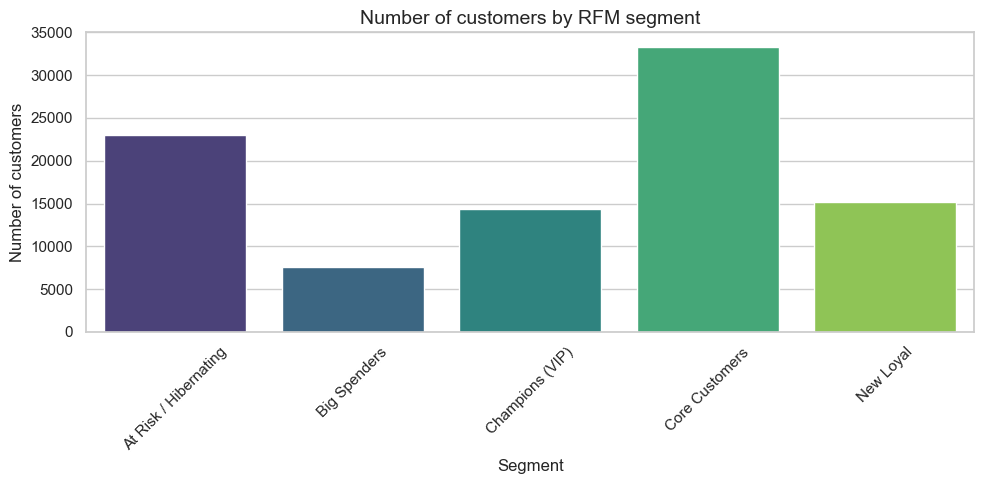

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_11982/1843641728.py:258: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm_df, x='customer_segment', y='total_revenue', palette='magma')


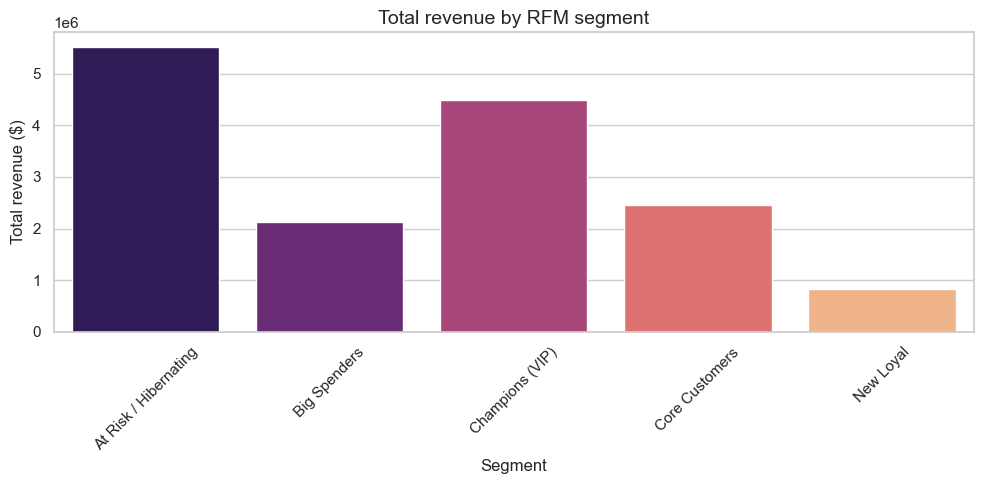

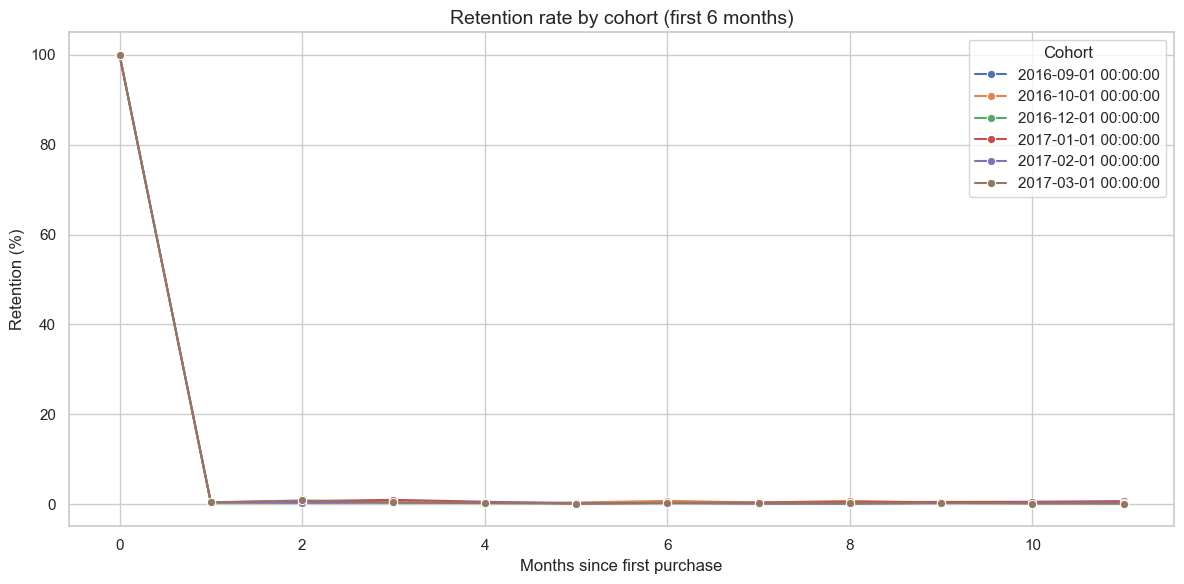

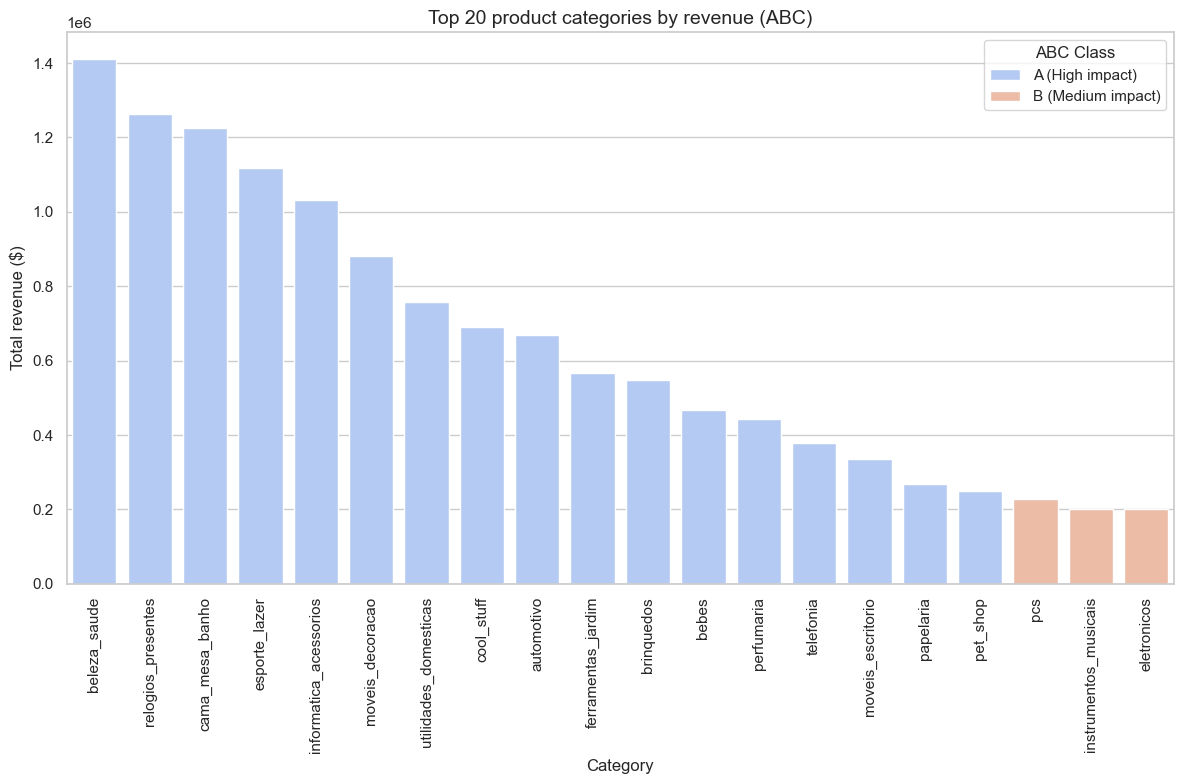


📊 General KPIs:
                                            0
total_orders                            96478
total_customers                         93358
total_products_sold                     32216
first_order_date          2016-09-15 12:16:38
last_order_date           2018-08-29 15:00:37
total_revenue                 15419773.749999
avg_ticket                         139.929161
avg_product_price                  119.980563
total_freight                      2198275.64
avg_freight                         19.948598
avg_orders_per_customer               1.03342
avg_revenue_per_customer            165.16821
orders_last_30d                             0
revenue_last_30d                          0.0
avg_ticket_last_30d                       0.0
revenue_per_customer                   165.17
revenue_per_order                      159.83


/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_11982/1843641728.py:304: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_plot, x='KPI', y='Count', palette='Blues_d')


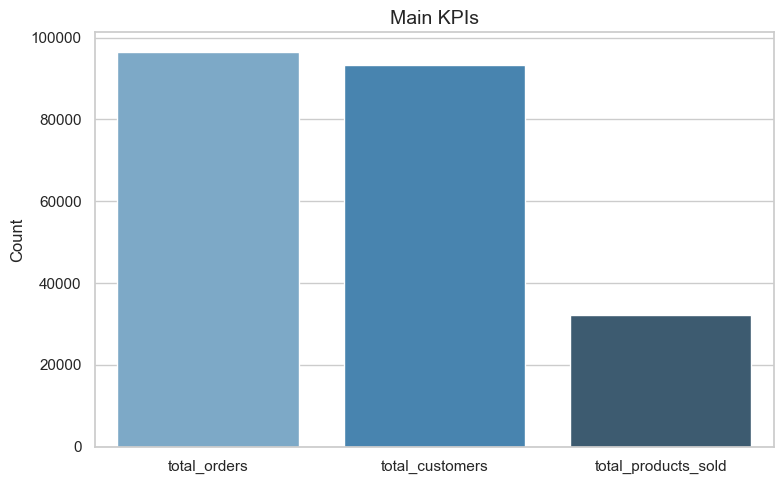

✅ Visualizations completed. Charts saved to the 'exports/' folder.


In [4]:
# ============================================================
# SQL Visualizations – Sales Analytics
# Quick exploratory charts using Python (Pandas, Matplotlib, Seaborn)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from pathlib import Path

# Configure style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Create exports folder in the project root (one level up from notebooks/)
exports_dir = Path.cwd().parent / "exports"
exports_dir.mkdir(exist_ok=True)
print(f"📁 Charts will be saved to: {exports_dir}")

# ---------------------------
# 1. Connect to PostgreSQL
# ---------------------------

DB_USER = "jesussanchez"
DB_PASSWORD = ""  # no password
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "olist_db"

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print("✅ Connection established.")

# ---------------------------
# 2. Load data from SQL queries
# ---------------------------

# RFM segmentation (get segment, customer count, and revenue)
rfm_query = """
WITH customer_metrics AS (
    SELECT 
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp::timestamp) AS last_purchase,
        COUNT(DISTINCT o.order_id) AS frequency,
        SUM(oi.price + oi.freight_value) AS monetary
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
reference_date AS (
    SELECT MAX(order_purchase_timestamp::timestamp) AS max_date FROM orders
),
rfm_scores AS (
    SELECT 
        customer_unique_id,
        EXTRACT(DAY FROM (SELECT max_date FROM reference_date) - last_purchase) AS recency_days,
        frequency,
        monetary,
        NTILE(5) OVER (ORDER BY EXTRACT(DAY FROM (SELECT max_date FROM reference_date) - last_purchase) ASC) AS recency_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS frequency_score,
        NTILE(5) OVER (ORDER BY monetary ASC) AS monetary_score
    FROM customer_metrics
)
SELECT 
    customer_unique_id,
    monetary,
    CASE 
        WHEN recency_score >= 4 AND frequency_score >= 4 AND monetary_score >= 4 THEN 'Champions (VIP)'
        WHEN monetary_score >= 4 AND recency_score >= 3 THEN 'Big Spenders'
        WHEN recency_score <= 2 AND frequency_score >= 3 THEN 'At Risk / Hibernating'
        WHEN recency_score >= 4 AND frequency_score <= 2 THEN 'New Loyal'
        ELSE 'Core Customers'
    END AS customer_segment
FROM rfm_scores
"""
rfm_raw = pd.read_sql(rfm_query, engine)
# Group by segment to get counts and revenue sum
rfm_df = rfm_raw.groupby('customer_segment').agg(
    num_customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum')
).reset_index()
print("RFM data loaded.")

# Cohort retention
cohort_query = """
WITH first_orders AS (
    SELECT 
        c.customer_unique_id,
        MIN(o.order_purchase_timestamp::timestamp) AS first_purchase,
        DATE_TRUNC('month', MIN(o.order_purchase_timestamp::timestamp)) AS cohort_month
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
cohort_activity AS (
    SELECT 
        f.cohort_month,
        f.customer_unique_id,
        DATE_TRUNC('month', o.order_purchase_timestamp::timestamp) AS activity_month,
        EXTRACT(MONTH FROM AGE(o.order_purchase_timestamp::timestamp, f.first_purchase)) AS month_offset
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN first_orders f ON c.customer_unique_id = f.customer_unique_id
    WHERE o.order_status = 'delivered'
)
SELECT 
    cohort_month,
    month_offset,
    COUNT(DISTINCT customer_unique_id) AS active_customers,
    FIRST_VALUE(COUNT(DISTINCT customer_unique_id)) OVER (PARTITION BY cohort_month ORDER BY month_offset) AS cohort_size,
    ROUND(
        100.0 * COUNT(DISTINCT customer_unique_id) / 
        FIRST_VALUE(COUNT(DISTINCT customer_unique_id)) OVER (PARTITION BY cohort_month ORDER BY month_offset),
        2
    ) AS retention_rate
FROM cohort_activity
GROUP BY cohort_month, month_offset
ORDER BY cohort_month, month_offset;
"""
cohort_df = pd.read_sql(cohort_query, engine)
print("Cohort data loaded.")

# ABC product classification
abc_query = """
WITH product_revenue AS (
    SELECT 
        p.product_category_name,
        SUM(oi.price + oi.freight_value) AS total_revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY p.product_category_name
),
abc_calc AS (
    SELECT 
        product_category_name,
        total_revenue,
        SUM(total_revenue) OVER (ORDER BY total_revenue DESC) AS cumulative_revenue,
        SUM(total_revenue) OVER () AS total_overall,
        ROUND(
            (100.0 * SUM(total_revenue) OVER (ORDER BY total_revenue DESC) / 
            SUM(total_revenue) OVER ())::numeric,
            2
        ) AS cumulative_percent
    FROM product_revenue
)
SELECT 
    product_category_name,
    total_revenue,
    cumulative_percent,
    CASE 
        WHEN cumulative_percent <= 80 THEN 'A (High impact)'
        WHEN cumulative_percent <= 95 THEN 'B (Medium impact)'
        ELSE 'C (Low impact)'
    END AS abc_class
FROM abc_calc
ORDER BY cumulative_percent ASC;
"""
abc_df = pd.read_sql(abc_query, engine)
print("ABC data loaded.")

# General KPIs
kpis_query = """
WITH 
base_metrics AS (
    SELECT
        COUNT(DISTINCT o.order_id) AS total_orders,
        COUNT(DISTINCT c.customer_unique_id) AS total_customers,
        COUNT(DISTINCT oi.product_id) AS total_products_sold,
        MIN(o.order_purchase_timestamp::timestamp) AS first_order_date,
        MAX(o.order_purchase_timestamp::timestamp) AS last_order_date,
        SUM(oi.price + oi.freight_value) AS total_revenue,
        AVG(oi.price + oi.freight_value) AS avg_ticket,
        AVG(oi.price) AS avg_product_price,
        SUM(oi.freight_value) AS total_freight,
        AVG(oi.freight_value) AS avg_freight
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),
customer_metrics AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS orders_per_customer,
        SUM(oi.price + oi.freight_value) AS revenue_per_customer
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
avg_per_customer AS (
    SELECT
        AVG(orders_per_customer) AS avg_orders_per_customer,
        AVG(revenue_per_customer) AS avg_revenue_per_customer
    FROM customer_metrics
),
last_30_days AS (
    SELECT
        COALESCE(COUNT(DISTINCT o.order_id), 0) AS orders_last_30d,
        COALESCE(SUM(oi.price + oi.freight_value), 0) AS revenue_last_30d,
        COALESCE(AVG(oi.price + oi.freight_value), 0) AS avg_ticket_last_30d
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp::timestamp >= (
          SELECT MAX(order_purchase_timestamp::timestamp) - INTERVAL '30 days'
          FROM orders
      )
)
SELECT
    b.total_orders,
    b.total_customers,
    b.total_products_sold,
    b.first_order_date,
    b.last_order_date,
    b.total_revenue,
    b.avg_ticket,
    b.avg_product_price,
    b.total_freight,
    b.avg_freight,
    a.avg_orders_per_customer,
    a.avg_revenue_per_customer,
    l.orders_last_30d,
    l.revenue_last_30d,
    l.avg_ticket_last_30d,
    ROUND((b.total_revenue / NULLIF(b.total_customers, 0))::numeric, 2) AS revenue_per_customer,
    ROUND((b.total_revenue / NULLIF(b.total_orders, 0))::numeric, 2) AS revenue_per_order
FROM base_metrics b
CROSS JOIN avg_per_customer a
CROSS JOIN last_30_days l;
"""
kpis_df = pd.read_sql(kpis_query, engine)
print("KPIs loaded.")

# ---------------------------
# 3. Visualizations
# ---------------------------

# 3.1 Number of customers per RFM segment
plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_df, x='customer_segment', y='num_customers', palette='viridis')
plt.title('Number of customers by RFM segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(exports_dir / 'rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.2 Total revenue per RFM segment
plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_df, x='customer_segment', y='total_revenue', palette='magma')
plt.title('Total revenue by RFM segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Total revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(exports_dir / 'rfm_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.3 Cohort retention (lines) - take the first 6 cohorts
plt.figure(figsize=(12, 6))
# Select the first 6 cohorts by date
cohorts_to_plot = sorted(cohort_df['cohort_month'].unique())[:6]
cohort_subset = cohort_df[cohort_df['cohort_month'].isin(cohorts_to_plot)]
if not cohort_subset.empty:
    sns.lineplot(data=cohort_subset, x='month_offset', y='retention_rate', hue='cohort_month', marker='o')
    plt.title('Retention rate by cohort (first 6 months)', fontsize=14)
    plt.xlabel('Months since first purchase')
    plt.ylabel('Retention (%)')
    plt.legend(title='Cohort')
    plt.tight_layout()
    plt.savefig(exports_dir / 'cohort_retention.png', dpi=150, bbox_inches='tight')
else:
    print("No cohort data available to plot.")
plt.show()

# 3.4 Top 20 categories by revenue with ABC classification
plt.figure(figsize=(12, 8))
abc_top = abc_df.head(20).sort_values('total_revenue', ascending=False)
sns.barplot(data=abc_top, x='product_category_name', y='total_revenue', hue='abc_class', dodge=False, palette='coolwarm')
plt.title('Top 20 product categories by revenue (ABC)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total revenue ($)')
plt.xticks(rotation=90)
plt.legend(title='ABC Class')
plt.tight_layout()
plt.savefig(exports_dir / 'abc_products.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.5 General KPIs: summary table and bar chart
print("\n📊 General KPIs:")
print(kpis_df.T)

# Bar chart with main KPIs (counts)
kpi_plot = kpis_df[['total_orders', 'total_customers', 'total_products_sold']].melt(var_name='KPI', value_name='Count')
plt.figure(figsize=(8, 5))
sns.barplot(data=kpi_plot, x='KPI', y='Count', palette='Blues_d')
plt.title('Main KPIs', fontsize=14)
plt.xlabel('')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(exports_dir / 'kpi_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualizations completed. Charts saved to the 'exports/' folder.")